=== Project Landing Page ===
Starting application...


--- Hospital Database ---
1. View All Patients
2. View Critical Patients
3. Add Patient
4. Plot Hospital Capacity (Analytics)
5. Exit


Select an option:  1


1. Patient 1: John Doe (DOB: 1985-04-12) - Diagnosis: Hypertension
2. Patient 2: Jane Smith (DOB: 1990-08-25) - Diagnosis: Asthma
3. Patient 3: Alice Johnson (DOB: 1978-11-03) - Diagnosis: Diabetes
4. Patient 4: Bob Brown (DOB: 2001-02-14) - Diagnosis: COVID-19
5. Patient 5: Charlie Davis (DOB: 1965-09-30) - Diagnosis: Heart Failure

--- Hospital Database ---
1. View All Patients
2. View Critical Patients
3. Add Patient
4. Plot Hospital Capacity (Analytics)
5. Exit


Select an option:  2


CRITICAL: Patient 2: Jane Smith (DOB: 1990-08-25) - Diagnosis: Asthma
CRITICAL: Patient 4: Bob Brown (DOB: 2001-02-14) - Diagnosis: COVID-19
CRITICAL: Patient 5: Charlie Davis (DOB: 1965-09-30) - Diagnosis: Heart Failure

--- Hospital Database ---
1. View All Patients
2. View Critical Patients
3. Add Patient
4. Plot Hospital Capacity (Analytics)
5. Exit


Select an option:  3
Enter Name:  Bao
Enter DOB (YYYY-MM-DD):  2002-10-27


Patient added successfully!

--- Hospital Database ---
1. View All Patients
2. View Critical Patients
3. Add Patient
4. Plot Hospital Capacity (Analytics)
5. Exit


Select an option:  4


Generating chart... Please close the window to continue.


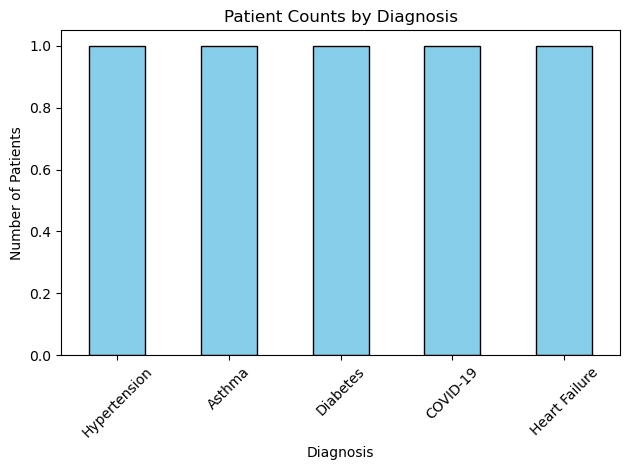


--- Hospital Database ---
1. View All Patients
2. View Critical Patients
3. Add Patient
4. Plot Hospital Capacity (Analytics)
5. Exit


Select an option:  1


1. Patient 1: John Doe (DOB: 1985-04-12) - Diagnosis: Hypertension
2. Patient 2: Jane Smith (DOB: 1990-08-25) - Diagnosis: Asthma
3. Patient 3: Alice Johnson (DOB: 1978-11-03) - Diagnosis: Diabetes
4. Patient 4: Bob Brown (DOB: 2001-02-14) - Diagnosis: COVID-19
5. Patient 5: Charlie Davis (DOB: 1965-09-30) - Diagnosis: Heart Failure
6. Patient 6: Bao (DOB: 2002-10-27) - Diagnosis: Undiagnosed

--- Hospital Database ---
1. View All Patients
2. View Critical Patients
3. Add Patient
4. Plot Hospital Capacity (Analytics)
5. Exit


Select an option:  2


CRITICAL: Patient 2: Jane Smith (DOB: 1990-08-25) - Diagnosis: Asthma
CRITICAL: Patient 4: Bob Brown (DOB: 2001-02-14) - Diagnosis: COVID-19
CRITICAL: Patient 5: Charlie Davis (DOB: 1965-09-30) - Diagnosis: Heart Failure

--- Hospital Database ---
1. View All Patients
2. View Critical Patients
3. Add Patient
4. Plot Hospital Capacity (Analytics)
5. Exit


In [ ]:
"""
Project entrypoint 
"""

from __future__ import annotations
import importlib
import subprocess
import sys
from pathlib import Path

from models import Patient, MedicalRecord
from data_manager import load_patient_data, get_critical_patients
from analytics import plot_hospital_capacity
from datetime import datetime

def validate_dob(dob_string: str) -> bool:
    '''
    Validates Date of Birth format to ensure it's not in the future.
    '''
    try:
        valid_date = datetime.strptime(dob_string, "%Y-%m-%d")
        if valid_date > datetime.now():
            raise ValueError("DOB cannot be in the future.")
        return True
    except ValueError as e:
        print(f"Invalid DOB Input: {e}")
        return False

def _run_streamlit() -> bool:
    streamlit_file = Path("streamlit_app.py")
    if streamlit_file.exists():
        subprocess.run([sys.executable, "-m", "streamlit", "run", str(streamlit_file)], check=False)
        return True
    return False


def _run_flask_like() -> bool:
    try:
        mod = importlib.import_module("app")
        app = getattr(mod, "app", None)
        if app is not None and hasattr(app, "run"):
            app.run(host="0.0.0.0", port=8000, debug=True)
            return True
    except Exception:
        pass
    return False


def _run_cli() -> bool:
    try:
        mod = importlib.import_module("cli")
        main = getattr(mod, "main", None)
        if callable(main):
            main()
            return True
    except Exception:
        pass
    return False


def main() -> None:
    print("=== Project Landing Page ===")
    print("Starting application...\n")

    filepath = 'patients.csv'
    patients_list = load_patient_data(filepath)
    db_running = True

    while db_running:
        print("\n--- Hospital Database ---")
        print("1. View All Patients")
        print("2. View Critical Patients")
        print("3. Add Patient")
        print("4. Plot Hospital Capacity (Analytics)")
        print("5. Exit")
        
        choice = input("Select an option: ")
        
        if choice == '1':
            for idx, p in enumerate(patients_list, start=1):
                print(f"{idx}. {p}")
        elif choice == '2':
            criticals = get_critical_patients(patients_list)
            for p in criticals:
                print(f"CRITICAL: {p}")
        elif choice == '3':
            name = input("Enter Name: ")
            dob = input("Enter DOB (YYYY-MM-DD): ")
            if validate_dob(dob):
                record = MedicalRecord("Undiagnosed", False, 0.0)
                new_p = Patient(len(patients_list) + 1, name, dob, record)
                patients_list.append(new_p)
                print("Patient added successfully!")
        elif choice == '4':
            print("Generating chart... Please close the window to continue.")
            plot_hospital_capacity(filepath)
        elif choice == '5':
            print("Shutting down system...")
            db_running = False
        else:
            print("Invalid selection.")

    if _run_streamlit():
        return
    if _run_flask_like():
        return
    if _run_cli():
        return

    print("No app entrypoint found.")
    print("Expected one of:")
    print("- streamlit_app.py")
    print("- app.py with `app` object")
    print("- cli.py with `main()`")


if __name__ == "__main__":
    main()